In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import ternary
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from Functions_OPEN_MINDEDNESS import *
from scipy.spatial.distance import pdist, squareform

## ABBIAMO INTRODOTTO L'OPEN MINDED INTERACTION

In [3]:
K = 3
N = 10
entropy_threshold = 1.2
popolazione_iniziale = generate_population(K,N, entropy_threshold)
o = calculate_total_overlap(popolazione_iniziale)                                           

In [4]:
t = 2000
eps = 0.1 
alpha = 0.0167
mu = 300
pop_finale   , storico  , storico_interaction = evolve_population( popolazione_iniziale , t , eps, alpha ,mu)

/Users/alicenappa/miniconda3/lib/python3.13/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


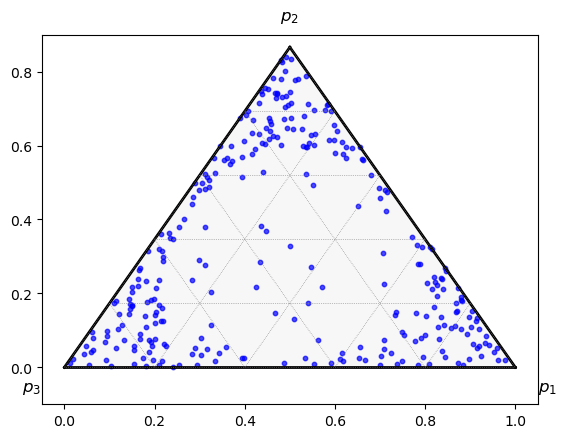

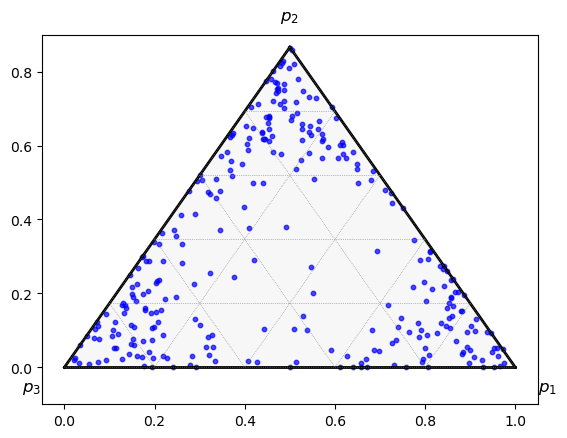

In [5]:
entropy_threshold =  1.2
alpha = 0.0167
N = 300
K=3
eps = 0.1

popolazione_iniziale = generate_population(K,N, entropy_threshold)
o = calculate_total_overlap(popolazione_iniziale)
pop_evoluta, storico, storico_interaction=evolve_population( popolazione_iniziale , t , eps, alpha ,mu)
plot_simplesso(popolazione_iniziale)
plot_simplesso(pop_evoluta)

FINAL COHESION VALUE 0.570966030755593


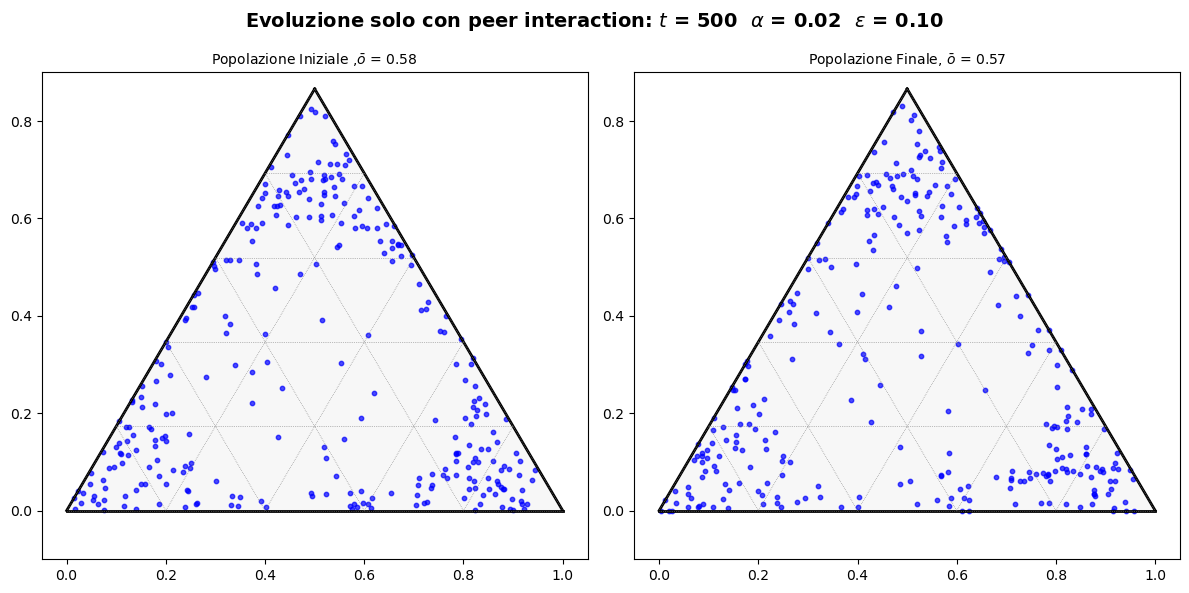

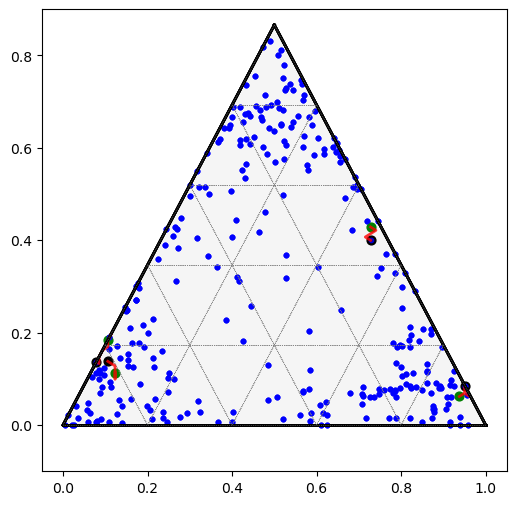

FINAL COHESION VALUE 0.5682606940729157


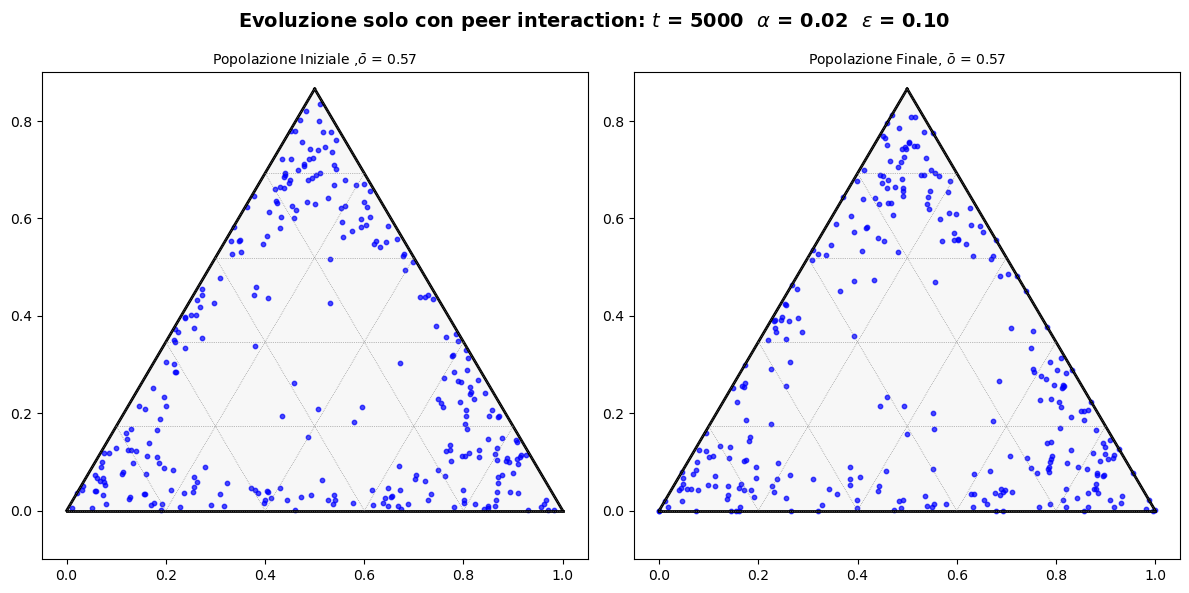

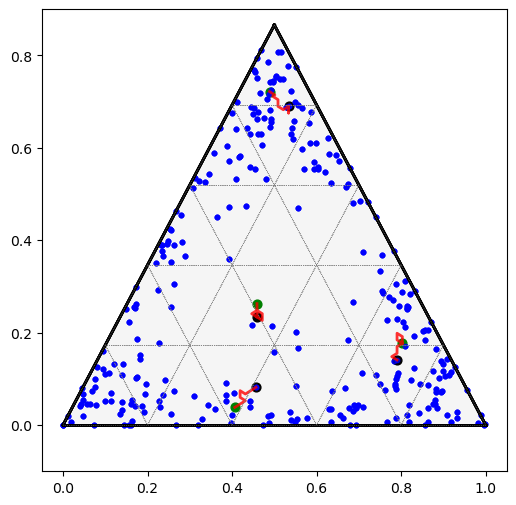

FINAL COHESION VALUE 0.5697777430219626


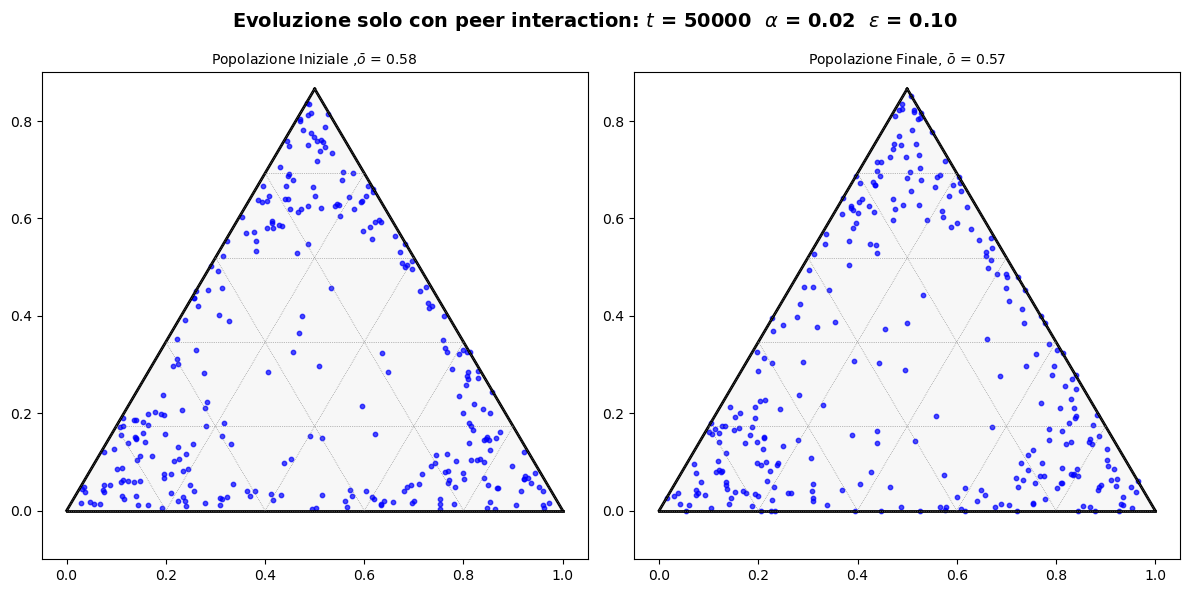

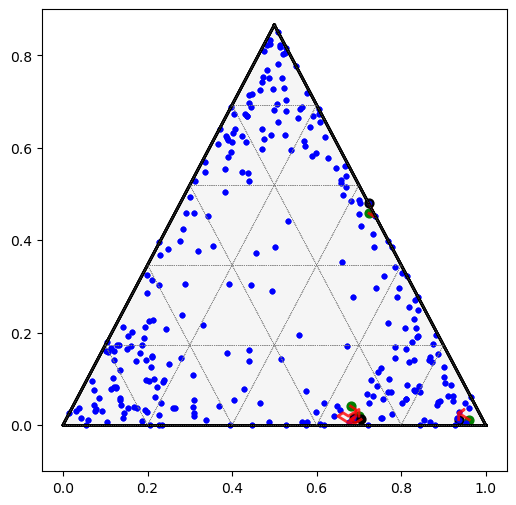

In [6]:
eps = 0.1
for time in [500, 5000, 50000]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    popolazione_iniziale = generate_population(K,N, entropy_threshold)
    o = calculate_total_overlap(popolazione_iniziale)
    plt.suptitle(rf"Evoluzione solo con peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} ", fontsize=14,  fontweight='bold')

    plot_simplesso_with_ax(popolazione_iniziale, axes[0], rf"Popolazione Iniziale ,$\bar{{o}}$ = {o:.2f}")
    pop_evoluta, storico, storico_interaction=evolve_population( popolazione_iniziale , t , eps, alpha ,mu)

    
    final_o =  calculate_total_overlap(pop_evoluta)
    title = f'traiettoria'

    print('FINAL COHESION VALUE' , final_o )
    plot_simplesso_with_ax(pop_evoluta, axes[1], rf"Popolazione Finale, $\bar{{o}}$ = {final_o:.2f}")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 6))
    index_user = 3 # Cambia questo per tracciare un altro individuo
    plot_user_trajectory_from_dict(storico, index_user, ax)
    plot_user_trajectory_from_dict(storico, 10, ax)
    plot_user_trajectory_from_dict(storico, 205, ax)
    plot_user_trajectory_from_dict(storico, 50, ax)
    
    plt.show()

# PARTE DI CLUSTERING -> OK FUNZIONA, ho controllato anche al variare di mu che desse sempre lo stesso risultato  

In [7]:
high_overlap = 2.2
low_overlap = 1.65

pop_high = generate_population(5 , 300, high_overlap)
pop_low =  generate_population(5 , 300, low_overlap) 

pop_finale_high, storico, storico_int_high = evolve_population( pop_high , 100000 , 0.1, 0.01 ,800)
pop_finale_low , storico , storico_int_low =evolve_population( pop_low  , 100000 , 0.1, 0.01 , 800)


In [8]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_cumulative_om(interaction_dict):
    all_times = set()
    om_counter = defaultdict(int)
    
    for individuo, tempi in interaction_dict.items():
        for tempo, interazioni in tempi.items():
            all_times.add(tempo)
            for interazione in interazioni:
                if interazione[0] == 'om':  # Tipo OM
                    om_counter[tempo] += 1

    # Ordina i tempi e calcola il cumulativo
    sorted_times = sorted(all_times)
    cumulative = 0
    cumulative_counts = []
    
    for t in sorted_times:
        cumulative += om_counter.get(t, 0)
        cumulative_counts.append(cumulative)

    # Crea il grafico
    plt.figure(figsize=(12,6))
    plt.step(sorted_times, cumulative_counts, where='post', color='b')
    plt.title('Conteggio cumulativo interazioni Open-Minded')
    plt.xlabel('Tempo')
    plt.ylabel('Totale interazioni OM')
    plt.grid(True)
    plt.show()

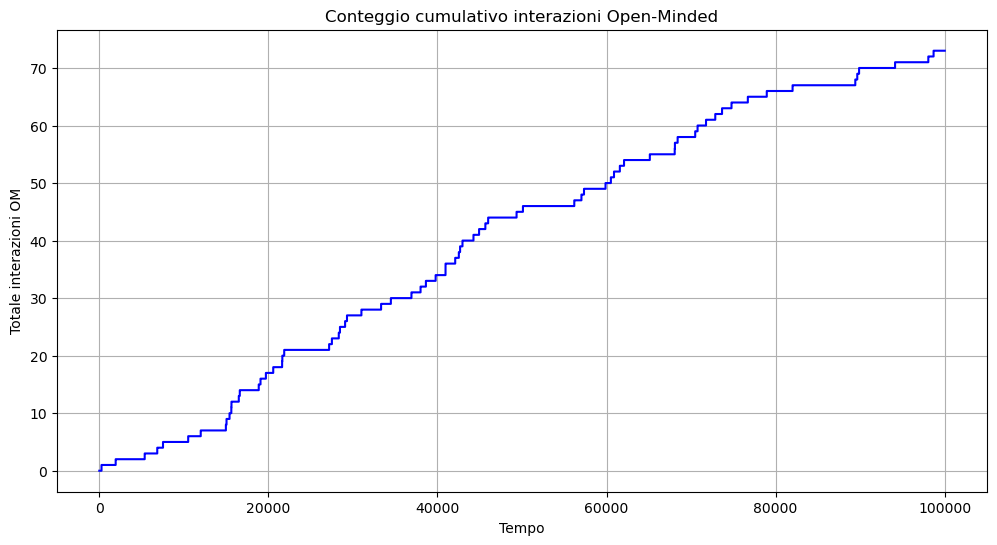

In [9]:
plot_cumulative_om(storico_int_high)

In [10]:
labels_high = hierarchical_clustering_K(pop_finale_high, similarity_threshold=0.8)
labels_low  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)


pr_high = compute_PR(labels_high)
pr_low  = compute_PR(labels_low)

print("PR high:", pr_high)  # Ci si aspetta PR ≈ 1
print("PR low:", pr_low)    # Ci si aspetta PR ≈ K 

PR high: 1.203369434416366
PR low: 4.81437894511608


In [11]:
### SEGNALIBRO : ho messo un w = 1 per vedere che succedeva quindi cambialo!!! 

### ORA DEVO AGGIUNGERE LA MODULATED INFORMATION 

In [12]:
PI = 0.5
K = 5
mu = 200
eps = 0.1
alpha = 0.01
time = 100000
pop_iniz = generate_population( K ,300, 2.2)

In [13]:
a_s = []
PR_low = []
for a_ in np.arange(0.2, 1, 0.1): 
    a_s.append(a_)
    I = external_info(K,a_)
    pop_finale   , storico  , storico_interaction =  evolve_population_with_info_and_peer_openm( pop_iniz , time , eps, alpha , I , PI , mu)
    labels  = hierarchical_clustering_K(pop_finale, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_low.append(pr)
    print('PR for a = ', a_, 'is PR= ', pr)

PR for a =  0.2 is PR=  1.0134222142149356
PR for a =  0.30000000000000004 is PR=  1.0
PR for a =  0.4000000000000001 is PR=  1.0
PR for a =  0.5000000000000001 is PR=  1.0
PR for a =  0.6000000000000001 is PR=  3.4052213393870603
PR for a =  0.7000000000000002 is PR=  4.984492689410722
PR for a =  0.8000000000000003 is PR=  4.960864292801235
PR for a =  0.9000000000000002 is PR=  4.959770748374297


In [14]:

# a_s = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
# PR_low = [1.0340311128472621, 1.0 ,1.0, 1.0 ,  3.514252245216712,4.979528604625429,4.964147821290679, 4.9977787649933365]
 

# Triggering consensus through moderate information

In [15]:
PI = 0.5
K = 5
mu = 200
eps = 0.1
alpha = 0.01
PR_HIGH = []
time = 100000
pop_iniz = generate_population( K ,300, 1.65)
for a_ in np.arange(0.2, 1, 0.1): 
    I = external_info(K,a_)
    
    pop_finale_low , storico , storico_int = evolve_population_with_info_and_peer_openm( pop_iniz , time , eps, alpha , I , PI , mu)
    labels  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_HIGH.append(pr)
    print('PR for a = ', a_, 'is PR= ', pr)

PR for a =  0.2 is PR=  1.1141923343567397
PR for a =  0.30000000000000004 is PR=  1.0
PR for a =  0.4000000000000001 is PR=  1.0
PR for a =  0.5000000000000001 is PR=  1.0
PR for a =  0.6000000000000001 is PR=  3.7291787519681776
PR for a =  0.7000000000000002 is PR=  4.916958041958042
PR for a =  0.8000000000000003 is PR=  4.900359359686377
PR for a =  0.9000000000000002 is PR=  4.926647689949639


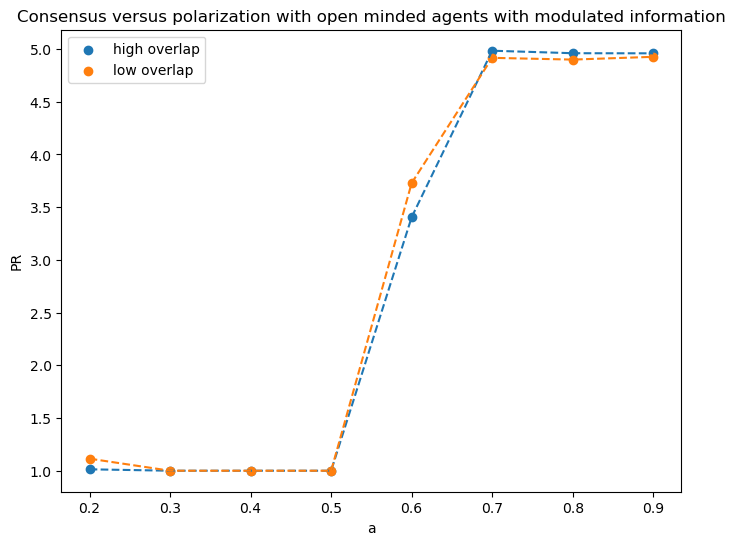

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(a_s , PR_low , '--')
plt.scatter(a_s , PR_low , label = 'high overlap')
plt.scatter(a_s , PR_HIGH, label = 'low overlap')
plt.plot(a_s , PR_HIGH , '--' )
plt.xlabel('a')
plt.title('Consensus versus polarization with open minded agents with modulated information')
plt.legend()
plt.ylabel('PR')
plt.show()